# スマートコントラクト

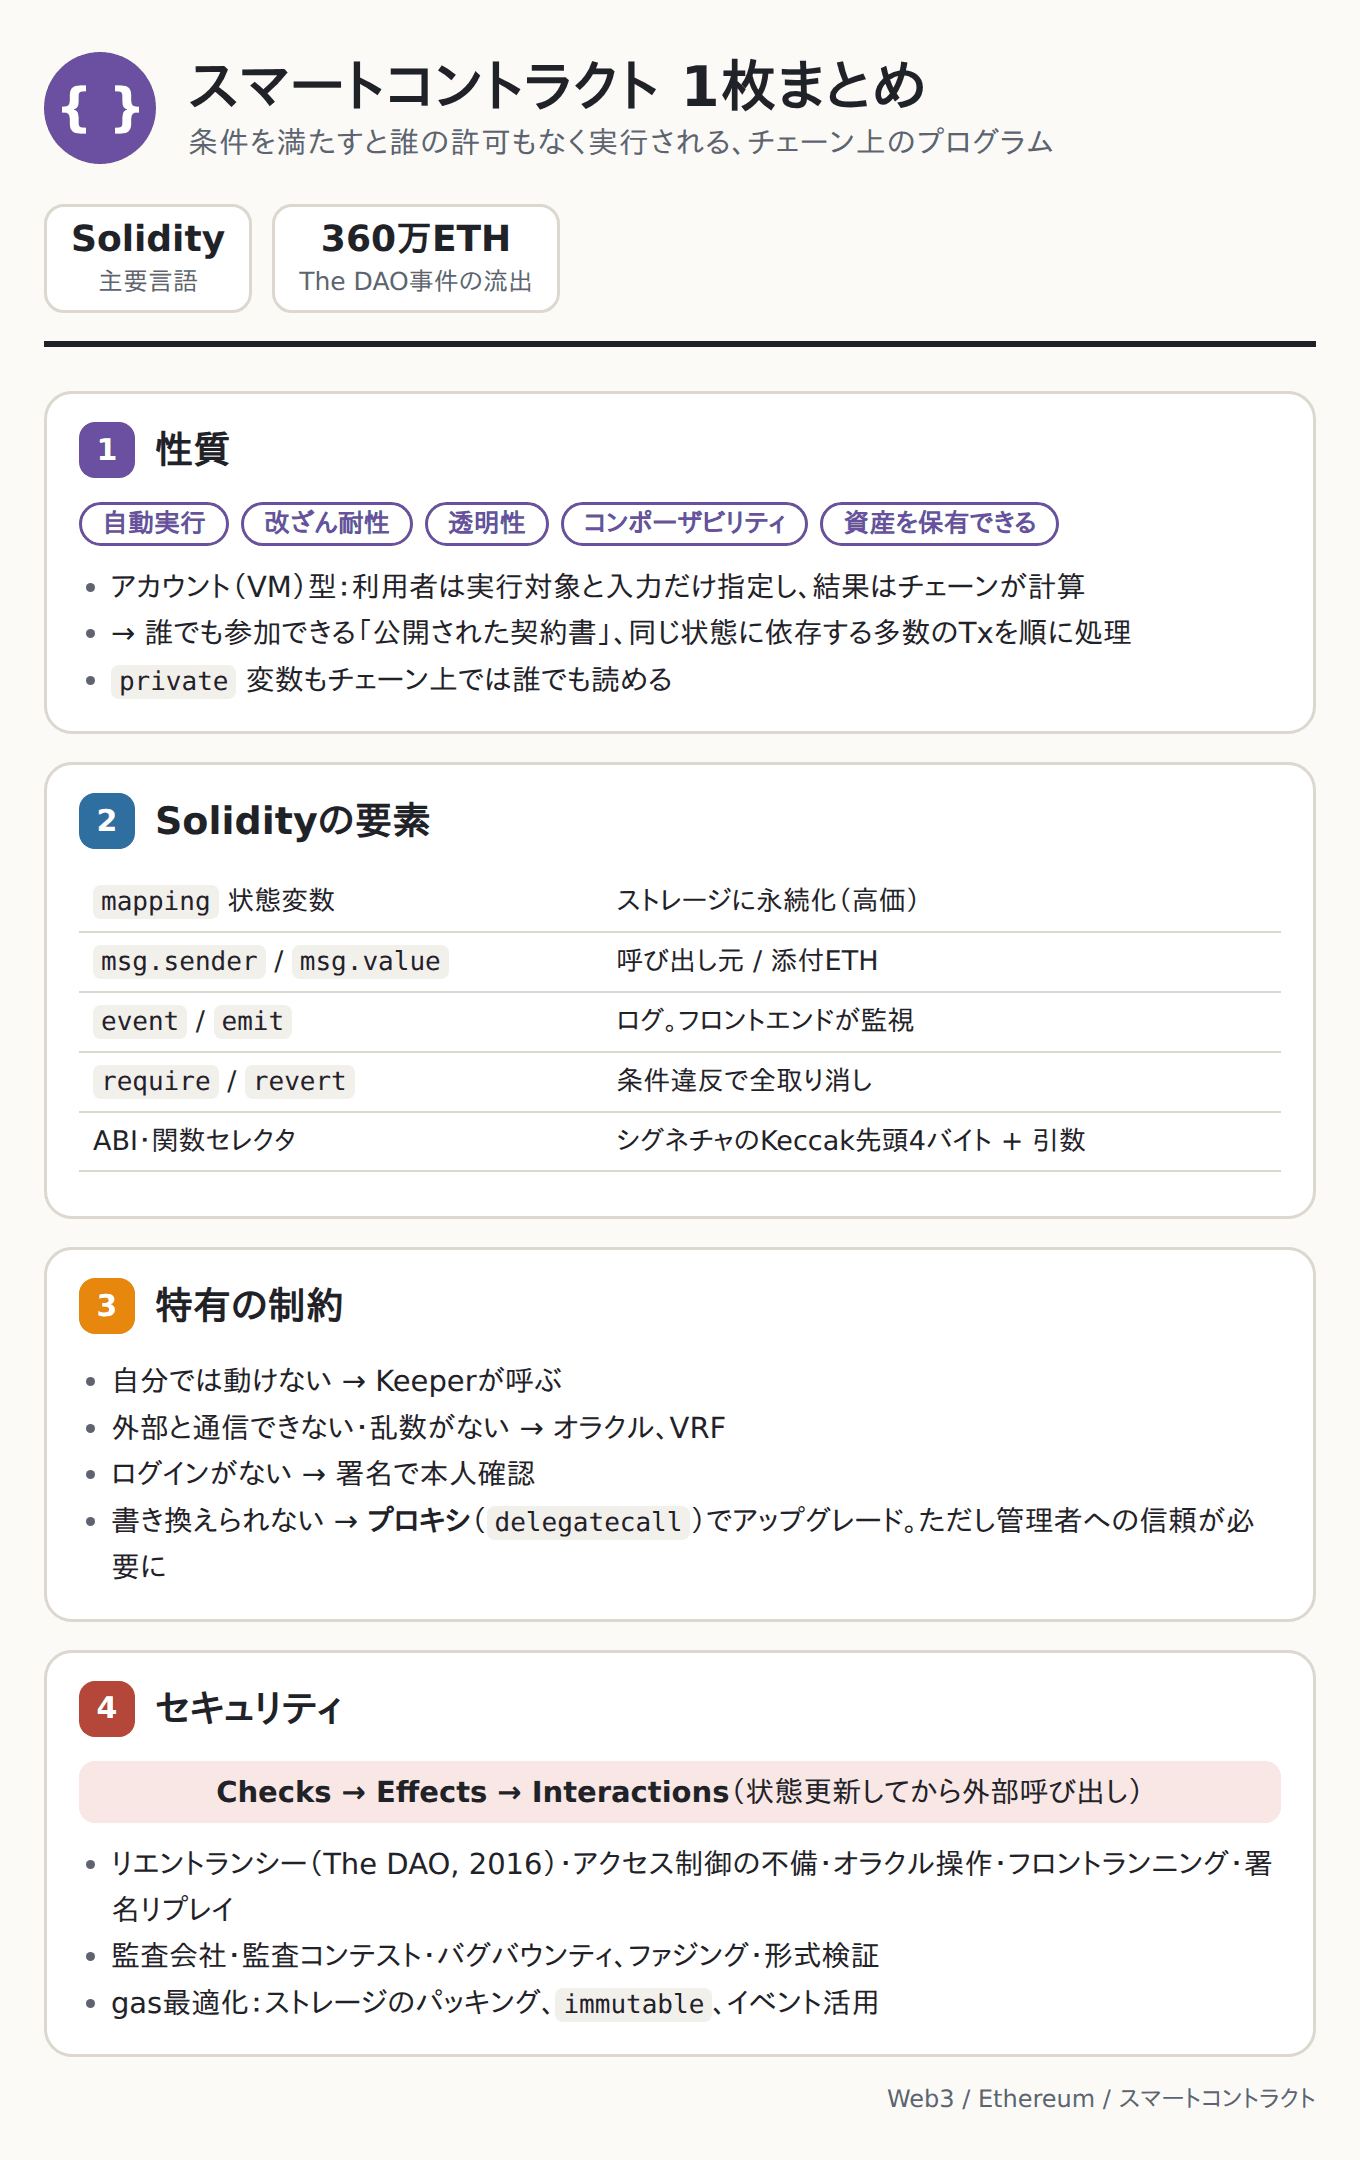

## スマートコントラクトとは

**スマートコントラクト（smart contract）** は、ブロックチェーン上にデプロイされ、条件を満たすと自動的に実行されるプログラム。概念自体はNick Szaboが1990年代に提唱したもので、自動販売機（お金を入れてボタンを押せば、店員なしで商品が出てくる）がしばしば例に挙げられる。

ブロックチェーン上のスマートコントラクトには次の性質がある。

| 性質 | 内容 |
| --- | --- |
| 自動実行 | 条件が満たされれば、誰の許可もなく実行される |
| 改ざん耐性 | デプロイしたコードは原則として変更できない |
| 透明性 | コードと実行履歴を誰でも検証できる |
| コンポーザビリティ | 他のコントラクトを自由に呼び出して組み合わせられる（「マネーレゴ」と呼ばれる） |
| 資産の保有 | コントラクト自身がETHやトークンを保有・管理できる |

最後の点は、BitcoinのようなUTXO型との大きな違いである。UTXO型では利用者が「実行後の状態」まで含めて署名するのに対し、Ethereumのようなアカウント（VM）型では、利用者は実行対象と入力だけを指定し、結果の状態はチェーン側が計算する。そのため、

- 誰でも条件を満たせば参加できる「公開された契約書」のようなものを作れる
- 同じ状態に依存する複数のトランザクションを、順番に処理できる（例：DEXのプールに多数の人が同時に注文を出す）

といったことが可能になる。

## Solidity

**Solidity** はEthereumのスマートコントラクトを書くための代表的な言語。構文はJavaScriptやC++に似ており、静的型付けでコントラクト指向の言語。他にPythonに似た **Vyper** などもある。

### 基本的な構造

```solidity
// SPDX-License-Identifier: MIT
pragma solidity ^0.8.24;

contract SimpleBank {
    // 状態変数（ストレージに永続化される）
    mapping(address => uint256) public balances;
    address public owner;

    // イベント（ログとして記録される）
    event Deposited(address indexed account, uint256 amount);
    event Withdrawn(address indexed account, uint256 amount);

    // カスタムエラー
    error InsufficientBalance(uint256 requested, uint256 available);

    // デプロイ時に1回だけ実行される
    constructor() {
        owner = msg.sender;
    }

    // payable: ETHを受け取れる関数
    function deposit() external payable {
        balances[msg.sender] += msg.value;
        emit Deposited(msg.sender, msg.value);
    }

    function withdraw(uint256 amount) external {
        uint256 balance = balances[msg.sender];
        if (amount > balance) revert InsufficientBalance(amount, balance);

        balances[msg.sender] = balance - amount;      // 先に状態を更新し
        (bool ok, ) = msg.sender.call{value: amount}(""); // 最後に外部呼び出し
        require(ok, "transfer failed");
        emit Withdrawn(msg.sender, amount);
    }

    // view: 状態を読むだけの関数（外部から呼ぶ場合はgas不要）
    function totalDeposits() external view returns (uint256) {
        return address(this).balance;
    }
}
```

### 主な要素

| 要素 | 内容 |
| --- | --- |
| 状態変数 | ストレージに保存される変数。読み書きにgasがかかる |
| `mapping(K => V)` | ハッシュマップ。キーの一覧は取得できない |
| `msg.sender` | この関数を呼び出したアカウント |
| `msg.value` | 呼び出しに添付されたETHの量（wei） |
| `block.timestamp`, `block.number` | ブロックの情報 |
| `event` / `emit` | ログを記録する。フロントエンドやインデクサーが監視する |
| `modifier` | 関数の前後に共通処理（権限チェックなど）を挿入する |
| `require` / `revert` | 条件を満たさなければ実行を取り消す |

関数の可視性：

| 修飾子 | 呼び出せる場所 |
| --- | --- |
| `public` | どこからでも |
| `external` | 外部からのみ |
| `internal` | 自身と継承先のコントラクト |
| `private` | 自身のみ |

`private` でも、ブロックチェーン上のデータは誰でも読めるため秘密にはならない点に注意。

状態の変更に関する修飾子：`view`（読むだけ）、`pure`（読みもしない）、`payable`（ETHを受け取れる）。

### ABIと関数セレクタ

コントラクトの関数を呼ぶとき、トランザクションの `data` には **関数セレクタ**（関数シグネチャのKeccak-256ハッシュの先頭4バイト）と、**ABI**（Application Binary Interface）の規則で32バイト単位にエンコードした引数が入る。

例えばERC-20の `transfer(address,uint256)` のセレクタは `0xa9059cbb`。

```
0xa9059cbb                                                         ← セレクタ
000000000000000000000000ab5801a7d398351b8be11c439e05c5b3259aec9b   ← address（32バイトに左詰め0埋め）
0000000000000000000000000000000000000000000000000de0b6b3a7640000   ← uint256（1e18）
```

コンパイラは関数の型情報をJSON形式の **ABIファイル** として出力し、フロントエンドのライブラリはこれを使って関数呼び出しをエンコード・デコードする。

## スマートコントラクト特有の制約

| 制約 | 内容 | 対処 |
| --- | --- | --- |
| 自分では動けない | トランザクションはEOAからしか発行できず、コントラクトが定期実行することはできない | 外部のボット（Keeper）が呼び出す。Chainlink Automation, Gelato など |
| 外部と通信できない | 決定論性を保つため、APIの呼び出しなどはできない | **オラクル** が外部データをチェーンに書き込む（→ オラクル問題） |
| 乱数が作れない | ブロックの値はブロック提案者がある程度操作できる | VRF（検証可能な乱数）を提供するオラクルを使う |
| ログインがない | セッションやパスワードの概念がない | 署名を検証して本人確認する（Sign-In with Ethereum など） |
| 書き換えられない | バグがあっても修正できない | プロキシパターンでアップグレード可能にする（ただし管理者への信頼が必要になる） |
| 計算資源の制約 | コードサイズ上限（24KB）、スタック深度、gasのコスト | 処理をオフチェーンに出す、gas最適化 |

### アップグレーダビリティ

コントラクトのコードは変更できないが、**プロキシパターン** で実質的にアップグレード可能にできる。

```mermaid
flowchart LR
    U["ユーザー"] -->|"call"| Proxy["Proxyコントラクト<br/>（ストレージを保持）"]
    Proxy -->|"delegatecall"| V1["Implementation v1<br/>（ロジックのみ）"]
    Proxy -.->|"アップグレード後"| V2["Implementation v2"]
```

`delegatecall` は、呼び出し先のコードを **呼び出し元のストレージの文脈で** 実行する命令。ユーザーは常にProxyのアドレスを使い、Proxyが参照するロジックのアドレスを差し替えることでアップグレードする（Transparent Proxy, UUPS（ERC-1822）, Beacon Proxy, Diamond（ERC-2535）などの方式がある）。

アップグレードできるということは、管理者がロジックを自由に変えられるということでもあり、トラストレス性とのトレードオフになる。マルチシグやタイムロック、DAOによるガバナンスで管理者の権限を制限するのが一般的。

## セキュリティ

スマートコントラクトは多額の資産を直接管理し、コードが公開され、デプロイ後の修正が難しいため、バグがそのまま資金の流出につながる。

### 主な脆弱性

| 脆弱性 | 内容 | 対策 |
| --- | --- | --- |
| リエントランシー（再入可能性） | 外部呼び出しの途中で、呼び出し先から元の関数を再度呼ばれ、状態更新前の残高で何度も引き出される | Checks-Effects-Interactionsパターン、ReentrancyGuard |
| アクセス制御の不備 | 管理者向けの関数を誰でも呼べてしまう | `onlyOwner` などの修飾子、ロールベースの権限管理 |
| 整数オーバーフロー | 演算結果が型の範囲を超えて巡回する | Solidity 0.8以降はデフォルトでチェックされる |
| オラクル操作 | 価格をDEXのスポット価格から取得していると、フラッシュローンで一時的に操作される | TWAP（時間加重平均価格）、Chainlinkなどの分散型オラクル |
| フロントランニング | mempoolで見えている取引の直前に自分の取引を割り込ませる（→ MEV） | スリッページ上限、commit-reveal方式、プライベートmempool |
| 署名のリプレイ | 同じ署名を別のチェーンや別の文脈で再利用される | nonce、chain_id、EIP-712の構造化署名 |

### リエントランシー

2016年の **The DAO事件** では、リエントランシーの脆弱性を突かれて当時約360万ETHが流出し、Ethereumがハードフォークで資金を巻き戻す事態になった（このとき分岐したもう一方のチェーンがEthereum Classic）。

```solidity
// 脆弱なコード
function withdraw() external {
    uint256 balance = balances[msg.sender];
    (bool ok, ) = msg.sender.call{value: balance}("");  // ← ここで攻撃者のコントラクトに制御が移り、
    require(ok);                                         //    withdraw() を再度呼ばれる
    balances[msg.sender] = 0;                            // ← 残高が0になる前なので何度でも引き出せる
}
```

攻撃者のコントラクトは、ETHを受け取ったときに実行される `receive()` 関数の中で `withdraw()` を再び呼ぶ。残高の更新が送金の後にあるため、残高が0になる前に何度も引き出せてしまう。

対策は **Checks-Effects-Interactions** パターン：条件のチェック → 状態の更新 → 外部呼び出し、の順に書く（上の `SimpleBank.withdraw` はこの順になっている）。

### 監査

本番環境にデプロイする前に、第三者によるセキュリティ監査を受けるのが一般的。

| 形態 | 概要 | 例 |
| --- | --- | --- |
| 監査会社 | 専門の監査人が数週間かけてレビュー | OpenZeppelin, Trail of Bits, Spearbit |
| 監査コンテスト | 多数の監査人が競争的に脆弱性を探し、見つけた重要度に応じて賞金を得る | Code4rena, Sherlock, Cantina |
| バグバウンティ | デプロイ後も継続的に、脆弱性の報告に賞金を出す | Immunefi |

あわせて、テスト、ファジング、形式検証（Certora, Halmos など）、静的解析（Slither など）を組み合わせる。

## gas最適化

ストレージの読み書きは非常に高いので、最適化の中心はストレージの扱いになる。

- **ストレージのパッキング**：ストレージは32バイト単位のスロットで管理される。小さい型の変数を隣り合わせに宣言すると1スロットにまとめられる

```solidity
contract Inefficient {
    uint128 a;  // スロット0
    uint256 b;  // スロット1
    uint128 c;  // スロット2
}

contract Efficient {
    uint128 a;  // スロット0の前半
    uint128 c;  // スロット0の後半
    uint256 b;  // スロット1
}
```

- ループの中でストレージ変数を何度も読まず、ローカル変数（メモリ）にコピーして使う
- 変更しない値は `constant` / `immutable` にする（ストレージを使わずコードに埋め込まれる）
- `require` の文字列の代わりにカスタムエラーを使う
- 履歴のように後から参照するだけのデータは、ストレージではなくイベントに記録する

## 参考文献

- [Solidity Documentation](https://docs.soliditylang.org/)
- [Solidity by Example](https://solidity-by-example.org/)
- [OpenZeppelin Contracts](https://docs.openzeppelin.com/contracts/)
- [SWC Registry](https://swcregistry.io/)（スマートコントラクトの脆弱性分類）
- [Ethernaut](https://ethernaut.openzeppelin.com/)（脆弱なコントラクトを攻略して学ぶCTF）